# Rare word / vocab coverage EDA

How many distinct words do we need to keep to cover 95% of word *occurrences*
(frequency mass) in each clean split (train / devv_eval / devv_test / test_set_no_answer)?

This is frequency-mass coverage, not PCA "variance" -- word counts have no natural variance
decomposition, so the analogous idea is: sort words by frequency, take cumulative share of
total token occurrences, find how many distinct words it takes to cross 95%.

Splits used (from `clean/`, already lowercased + alnum-filtered by clean_alnum.py):
- `train.src.tok` -- training corpus, one sentence per line
- `devv_eval.csv` / `devv_test.csv` -- `context` column (tuning / holdout)
- `test_set_no_answer.csv` -- `context` column, no answer


In [1]:
from collections import Counter
from pathlib import Path
import csv

CLEAN = Path("../clean")


In [2]:
def count_corpus_file(path):
    """Word counts for a one-sentence-per-line token file (train.src.tok)."""
    c = Counter()
    with open(path, encoding="utf-8") as f:
        for line in f:
            c.update(line.split())
    return c


def count_context_csv(path):
    """Word counts for the 'context' column of a cleaned csv."""
    c = Counter()
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            c.update(row["context"].split())
    return c


In [3]:
counts = {
    "train": count_corpus_file(CLEAN / "train.src.tok"),
    "devv_eval": count_context_csv(CLEAN / "devv_eval.csv"),
    "devv_test": count_context_csv(CLEAN / "devv_test.csv"),
    "test_no_answer": count_context_csv(CLEAN / "test_set_no_answer.csv"),
}
for name, c in counts.items():
    print(f"{name}: {len(c):,} distinct words, {sum(c.values()):,} total occurrences")


train: 98,993 distinct words, 112,721,986 total occurrences
devv_eval: 41,241 distinct words, 1,708,224 total occurrences
devv_test: 23,997 distinct words, 426,822 total occurrences
test_no_answer: 44,427 distinct words, 2,130,774 total occurrences


## Coverage: words needed for 95% of occurrences

Sort words by frequency descending, accumulate, stop once cumulative share crosses the
threshold.

In [4]:
def coverage_table(counter, thresholds=(0.90, 0.95, 0.99)):
    total = sum(counter.values())
    freqs = sorted(counter.values(), reverse=True)
    cum = 0
    n_at = {}
    remaining = list(thresholds)
    for i, f in enumerate(freqs, start=1):
        cum += f
        while remaining and cum / total >= remaining[0]:
            n_at[remaining.pop(0)] = i
        if not remaining:
            break
    for t in remaining:  # threshold never reached (shouldn't happen at <=99%)
        n_at[t] = len(freqs)
    return n_at, len(freqs), total


rows = []
for name, c in counts.items():
    n_at, vocab_size, total = coverage_table(c)
    row = {"split": name, "vocab_size": vocab_size, "total_tokens": total}
    for t, n in n_at.items():
        row[f"words_for_{int(t*100)}pct"] = n
        row[f"pct_of_vocab_{int(t*100)}"] = round(100 * n / vocab_size, 2)
    rows.append(row)

import pandas as pd
df = pd.DataFrame(rows).set_index("split")
df


,vocab_size,total_tokens,words_for_90pct,pct_of_vocab_90,words_for_95pct,pct_of_vocab_95,words_for_99pct,pct_of_vocab_99
split,,,,,,,,
train,98993,112721986,4998,5.05,10147,10.25,32988,33.32
devv_eval,41241,1708224,4859,11.78,9607,23.29,25636,62.16
devv_test,23997,426822,4704,19.60,8902,37.10,19729,82.21
test_no_answer,44427,2130774,4866,10.95,9654,21.73,26492,59.63


## Threshold cliff: words needed vs. coverage target

Push the threshold higher (90% -> 99.9%) and see where words-needed stops being worth it --
the long tail of singletons makes the last few percent disproportionately expensive.

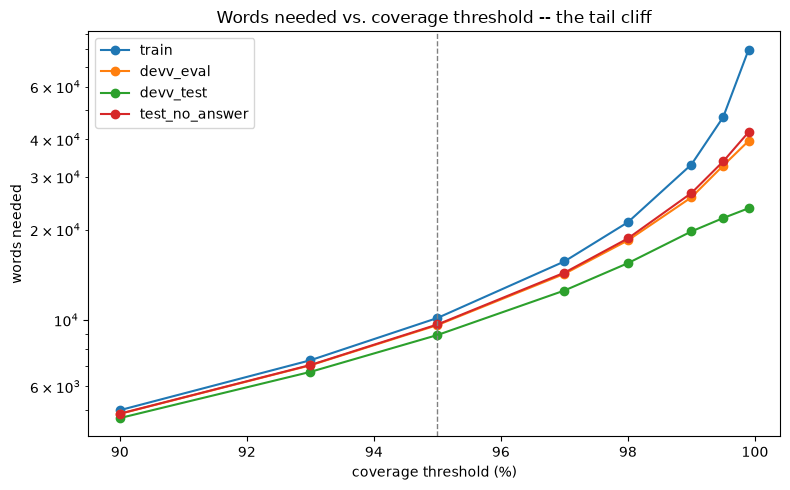

In [5]:
import matplotlib.pyplot as plt

fine_thresholds = [0.90, 0.93, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]

fig, ax = plt.subplots(figsize=(8, 5))
for name, c in counts.items():
    n_at, vocab_size, total = coverage_table(c, fine_thresholds)
    xs = [t * 100 for t in fine_thresholds]
    ys = [n_at[t] for t in fine_thresholds]
    ax.plot(xs, ys, marker="o", label=name)

ax.axvline(95, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("coverage threshold (%)")
ax.set_ylabel("words needed")
ax.set_yscale("log")
ax.set_title("Words needed vs. coverage threshold -- the tail cliff")
ax.legend()
plt.tight_layout()
plt.show()

## Cumulative coverage curve

Rank (log scale) vs. cumulative share of occurrences. Marks the 95% line and how many words
it takes to reach it, per split.

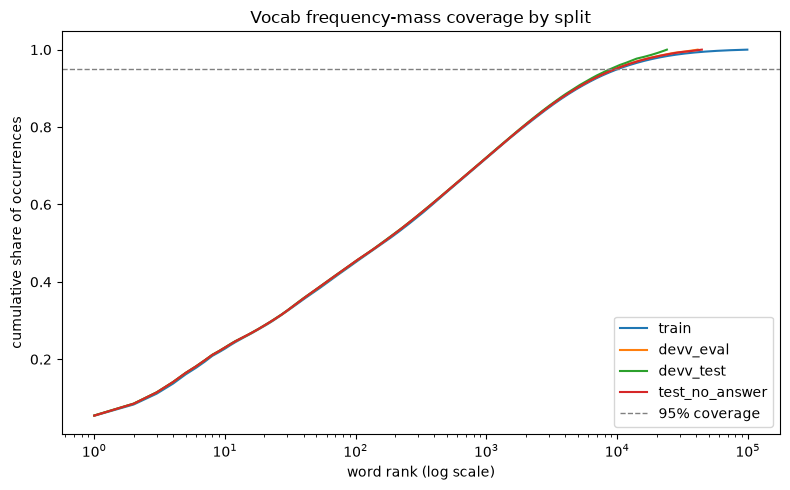

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for name, c in counts.items():
    freqs = sorted(c.values(), reverse=True)
    total = sum(freqs)
    cum = []
    running = 0
    for f in freqs:
        running += f
        cum.append(running / total)
    ax.plot(range(1, len(cum) + 1), cum, label=name)

ax.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="95% coverage")
ax.set_xscale("log")
ax.set_xlabel("word rank (log scale)")
ax.set_ylabel("cumulative share of occurrences")
ax.set_title("Vocab frequency-mass coverage by split")
ax.legend()
plt.tight_layout()
plt.show()


## Rarest words

Long tail: how many words occur only once (hapax legomena) per split -- these are the ones a
frequency-coverage vocab cutoff drops first.

In [7]:
for name, c in counts.items():
    hapax = sum(1 for v in c.values() if v == 1)
    print(f"{name}: {hapax:,} hapax legomena "
          f"({100*hapax/len(c):.1f}% of distinct words, {100*hapax/sum(c.values()):.3f}% of occurrences)")


train: 3 hapax legomena (0.0% of distinct words, 0.000% of occurrences)
devv_eval: 14,128 hapax legomena (34.3% of distinct words, 0.827% of occurrences)
devv_test: 10,129 hapax legomena (42.2% of distinct words, 2.373% of occurrences)
test_no_answer: 14,563 hapax legomena (32.8% of distinct words, 0.683% of occurrences)
